Charger les données et faire un petit resumer  Shape: (ligne, col)

In [1]:
import sys
sys.path.append("../src")

from utils import load_all_data

dfs = load_all_data()  # Charge tout

# Afficher le résumé de chaque DataFrame
for key, df in dfs.items():  # on itère sur dfs, pas files
    print(f"\n{'='*50}")
    print(f"Fichier : {key}")
    print(f"Shape   : {df.shape}")
    print(f"Colonnes: {list(df.columns)}")
    print(df.head(3))



Fichier : inactive
Shape   : (17820, 6)
Colonnes: ['ccode', 'year', 'gender', 'age_group', 'edu_ilo', 'neet_fc']
  ccode  year  gender age_group          edu_ilo  neet_fc
0   AGO  2015  Female     15-24  Lower Secondary  0.26543
1   AGO  2016  Female     15-24  Lower Secondary  0.27917
2   AGO  2017  Female     15-24  Lower Secondary  0.28672

Fichier : student
Shape   : (1166000, 7)
Colonnes: ['ccode', 'year', 'age', 'gender', 'education', 'status', 'population']
  ccode  year  age  gender        education    status  population
0   AGO  2015   15  female          primary  employed     66917.0
1   AGO  2015   15  female  upper secondary  employed      3061.0
2   AGO  2015   15  female  lower secondary  employed     10286.0

Fichier : unemployed
Shape   : (17820, 7)
Colonnes: ['ccode', 'year', 'edu_ilo', 'age_group', 'gender', 'share_unemp', 'share_inact']
  ccode  year            edu_ilo age_group  gender  share_unemp  share_inact
0   AGO  2015  Less than primary     15-24  female    

In [2]:
#aperçu global des chiffres
print(dfs["sector"].describe())

               year           age    population
count  1.224300e+06  1.224300e+06  1.224300e+06
mean   2.020000e+03  3.950000e+01  4.187975e+03
std    3.162279e+00  1.443088e+01  2.164336e+04
min    2.015000e+03  1.500000e+01  0.000000e+00
25%    2.017000e+03  2.700000e+01  4.900000e+01
50%    2.020000e+03  3.950000e+01  2.590000e+02
75%    2.023000e+03  5.200000e+01  1.371000e+03
max    2.025000e+03  6.400000e+01  9.089370e+05


In [3]:
# Pour voir quels pays sont inclus (ex: CI pour Côte d'Ivoire)
for key, df in dfs.items():
    pours_uniques = sorted(df['ccode'].unique())
    print(f"\n Liste des pays dans {key} ({len(pours_uniques)} pays) :")
    print(pours_uniques)


 Liste des pays dans inactive (54 pays) :
['AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'COG', 'COM', 'CPV', 'DJI', 'DZA', 'EGY', 'ERI', 'ETH', 'GAB', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'KEN', 'LBR', 'LBY', 'LSO', 'MAR', 'MDG', 'MLI', 'MOZ', 'MRT', 'MUS', 'MWI', 'NAM', 'NER', 'NGA', 'RWA', 'SDN', 'SEN', 'SLE', 'SOM', 'SSD', 'STP', 'SWZ', 'SYC', 'TCD', 'TGO', 'TUN', 'TZA', 'UGA', 'ZAF', 'ZMB', 'ZWE']

 Liste des pays dans student (53 pays) :
['AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'COG', 'COM', 'CPV', 'DJI', 'DZA', 'EGY', 'ERI', 'ETH', 'GAB', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'KEN', 'LBR', 'LBY', 'LSO', 'MAR', 'MDG', 'MLI', 'MOZ', 'MRT', 'MUS', 'MWI', 'NAM', 'NER', 'NGA', 'RWA', 'SDN', 'SEN', 'SLE', 'SOM', 'SSD', 'STP', 'SWZ', 'TCD', 'TGO', 'TUN', 'TZA', 'UGA', 'ZAF', 'ZMB', 'ZWE']

 Liste des pays dans unemployed (54 pays) :
['AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'COG', 'COM', 'CPV', 'DJI', 'DZA', 'EGY', 'ERI', 'ETH',

graphique rapide pour les 5 premiers pays du fichier student

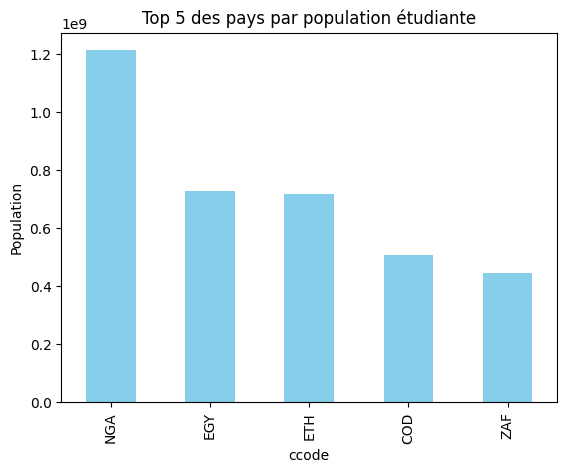

In [4]:
import matplotlib.pyplot as plt

top_5_students = dfs['student'].groupby('ccode')['population'].sum().nlargest(5)
top_5_students.plot(kind='bar', color='skyblue')
plt.title("Top 5 des pays par population étudiante")
plt.ylabel("Population")
plt.show()

In [2]:
# Cellule précédente — extraction des DataFrames
import sys
sys.path.append("../src")
from utils import load_all_data

dfs = load_all_data()
inactive  = dfs["inactive"]
student   = dfs["student"]
formality = dfs["formality"]
employed  = dfs["employed_ur"]   
sector    = dfs["sector"]



# Vérification des tranches d'âge dans chaque dataset
print("=== INACTIVE ===")
print("age_group:", inactive['age_group'].unique())

print("\n=== STUDENT ===")
print("age:", sorted(student['age'].unique()))

print("\n=== FORMALITY ===")
print("age:", sorted(formality['age'].unique()))
print("age_group:", formality['age_group'].unique() if 'age_group' in formality.columns else "pas de colonne age_group")

print("\n=== EMPLOYED_UR ===")
print("age:", sorted(employed['age'].unique()))
print("age_group:", employed['age_group'].unique())

print("\n=== SECTOR ===")
print("age:", sorted(sector['age'].unique()))

=== INACTIVE ===
age_group: ['15-24', '25-54', '55-64']
Categories (3, str): ['15-24', '25-54', '55-64']

=== STUDENT ===
age: [np.int8(15), np.int8(16), np.int8(17), np.int8(18), np.int8(19), np.int8(20), np.int8(21), np.int8(22), np.int8(23), np.int8(24), np.int8(25), np.int8(26), np.int8(27), np.int8(28), np.int8(29), np.int8(30), np.int8(31), np.int8(32), np.int8(33), np.int8(34), np.int8(35), np.int8(36), np.int8(37), np.int8(38), np.int8(39), np.int8(40), np.int8(41), np.int8(42), np.int8(43), np.int8(44), np.int8(45), np.int8(46), np.int8(47), np.int8(48), np.int8(49), np.int8(50), np.int8(51), np.int8(52), np.int8(53), np.int8(54), np.int8(55), np.int8(56), np.int8(57), np.int8(58), np.int8(59), np.int8(60), np.int8(61), np.int8(62), np.int8(63), np.int8(64)]

=== FORMALITY ===
age: [np.int8(15), np.int8(16), np.int8(17), np.int8(18), np.int8(19), np.int8(20), np.int8(21), np.int8(22), np.int8(23), np.int8(24), np.int8(25), np.int8(26), np.int8(27), np.int8(28), np.int8(29), np